# TD-1 Data Analysis in Python: pandas, seaborn, and NumPy

The order is:
1. **pandas + seaborn**
2. **NumPy**

The datasets are stored in the folder `data/` next to this notebook:
- `data/Iris.csv`
- `data/s1.csv`

This is the **complete solution version** of the notebook.


In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 1. pandas and seaborn


We begin with **tabular data manipulation** using `pandas`, then we move to **statistical visualization** with `seaborn`.


### 1.1 pandas Series: creation


In [60]:
a = pd.Series([1, 2, 3])
a

b = pd.Series(["foo", "bar", "baz"])
b

c = np.array([1, 2, 3])
d = pd.Series(c)
d


0    1
1    2
2    3
dtype: int64

0    foo
1    bar
2    baz
dtype: object

0    1
1    2
2    3
dtype: int32

### 1.2 pandas Series: index and access


In [61]:
age = pd.Series([23, 24, 24, 25], index=["Agathe", "Beatrice", "Cedric", "Donna"])
age
age.index
age["Cedric"]


Agathe      23
Beatrice    24
Cedric      24
Donna       25
dtype: int64

Index(['Agathe', 'Beatrice', 'Cedric', 'Donna'], dtype='object')

24

### 1.3 DataFrame: creation


In [62]:
df_people = pd.DataFrame({
    "name": ["Alice", "Bob", "Clara"],
    "age": [21, 25, 22],
    "city": ["Lyon", "Paris", "Lille"]
})
df_people


,name,age,city
0,Alice,21,Lyon
1,Bob,25,Paris
2,Clara,22,Lille


### 1.4 Load the Iris dataset


In [63]:
df = pd.read_csv("data/Iris.csv")
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 1.5 First inspection


In [64]:
df.shape
df.columns
df.dtypes
df.info()
df.describe()


(150, 6)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### 1.6 Column selection and row selection


In [65]:
df["SepalLengthCm"].head()
df[["SepalLengthCm", "Species"]].head()
df.iloc[:5]
df.iloc[0]


0    5.1
1    4.9
2    4.7
3    4.6
4    5.0
Name: SepalLengthCm, dtype: float64

,SepalLengthCm,Species
0,5.1,Iris-setosa
1,4.9,Iris-setosa
2,4.7,Iris-setosa
3,4.6,Iris-setosa
4,5.0,Iris-setosa


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Id                         1
SepalLengthCm            5.1
SepalWidthCm             3.5
PetalLengthCm            1.4
PetalWidthCm             0.2
Species          Iris-setosa
Name: 0, dtype: object

### 1.7 Filtering


In [66]:
long_sepals = df[df["SepalLengthCm"] >= 6.0]
long_sepals.head()

setosa_only = df[df["Species"] == "Iris-setosa"]
setosa_only.head()

wide_petals = df[df["PetalWidthCm"] > 2.0]
wide_petals.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor
56,57,6.3,3.3,4.7,1.6,Iris-versicolor


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
100,101,6.3,3.3,6.0,2.5,Iris-virginica
102,103,7.1,3.0,5.9,2.1,Iris-virginica
104,105,6.5,3.0,5.8,2.2,Iris-virginica
105,106,7.6,3.0,6.6,2.1,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica


### 1.8 Descriptive statistics


In [67]:
df["SepalLengthCm"].mean()
df["Species"].value_counts()
df["PetalLengthCm"].describe()


5.843333333333334

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

count    150.000000
mean       3.758667
std        1.764420
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: PetalLengthCm, dtype: float64

### 1.9 GroupBy


In [68]:
df.groupby("Species")["SepalLengthCm"].mean()
df.groupby("Species")["PetalLengthCm"].mean()


Species
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: SepalLengthCm, dtype: float64

Species
Iris-setosa        1.464
Iris-versicolor    4.260
Iris-virginica     5.552
Name: PetalLengthCm, dtype: float64

### 1.10 New columns and sorting


In [69]:
df["sepal_area"] = df["SepalLengthCm"] * df["SepalWidthCm"]
df["petal_area"] = df["PetalLengthCm"] * df["PetalWidthCm"]

df.sort_values(by="sepal_area", ascending=False).head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,sepal_area,petal_area
131,132,7.9,3.8,6.4,2.0,Iris-virginica,30.02,12.80
117,118,7.7,3.8,6.7,2.2,Iris-virginica,29.26,14.74
109,110,7.2,3.6,6.1,2.5,Iris-virginica,25.92,15.25
15,16,5.7,4.4,1.5,0.4,Iris-setosa,25.08,0.60
14,15,5.8,4.0,1.2,0.2,Iris-setosa,23.20,0.24


### 1.11 Missing values


In [70]:
df.isnull().sum()

df_clean = df.dropna().copy()
df_clean.shape


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
sepal_area       0
petal_area       0
dtype: int64

(150, 8)

## 2. seaborn visualizations


In this section, we use `seaborn` to quickly visualize distributions, group differences, and relationships between variables.


### 2.1 Scatter plot


<Figure size 700x500 with 0 Axes>

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

Text(0.5, 1.0, 'Sepal length vs petal length')

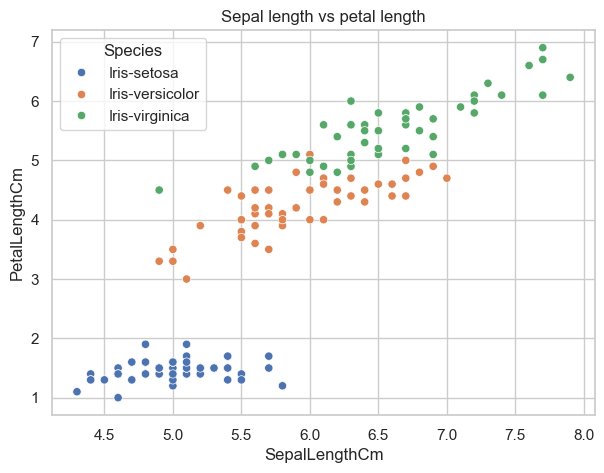

In [71]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="SepalLengthCm", y="PetalLengthCm", hue="Species")
plt.title("Sepal length vs petal length")
plt.show()


### 2.2 Histogram


<Figure size 700x500 with 0 Axes>

<Axes: xlabel='SepalLengthCm', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of sepal length')

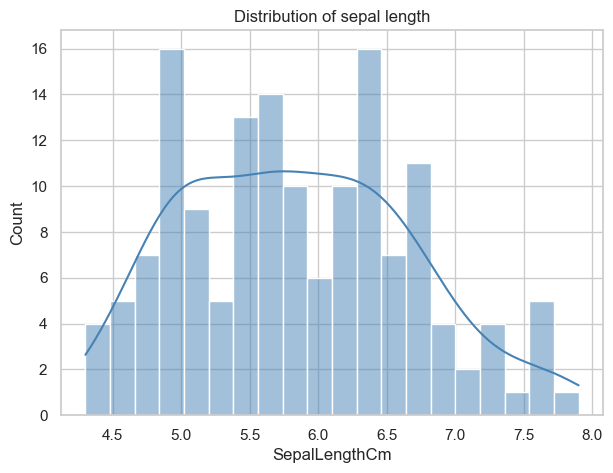

In [72]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="SepalLengthCm", bins=20, kde=True, color="steelblue")
plt.title("Distribution of sepal length")
plt.show()


### 2.3 Boxplot


<Figure size 700x500 with 0 Axes>

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

Text(0.5, 1.0, 'Petal length by species')

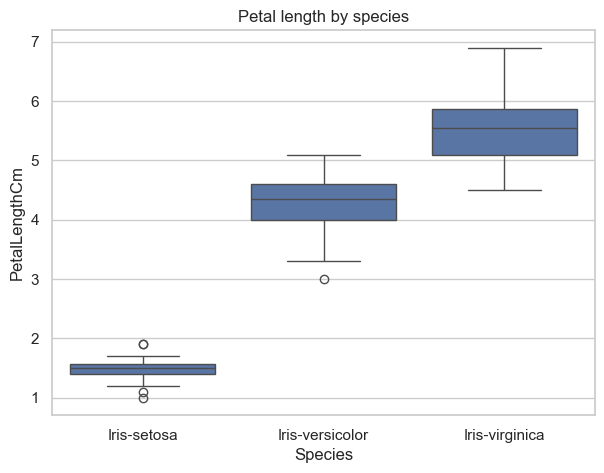

In [73]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Species", y="PetalLengthCm")
plt.title("Petal length by species")
plt.show()


### 2.4 Violin plot


<Figure size 700x500 with 0 Axes>

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

Text(0.5, 1.0, 'Sepal width by species')

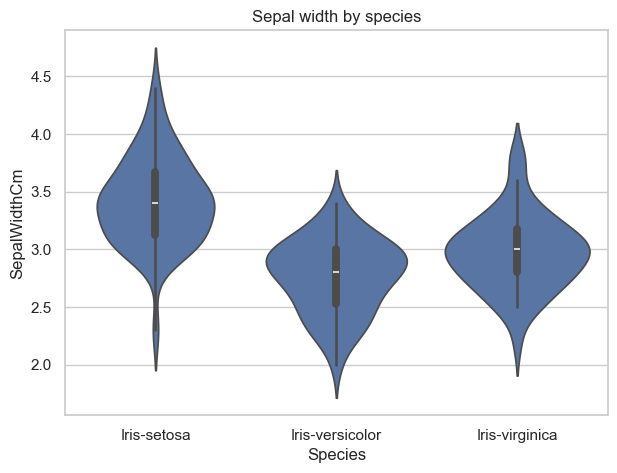

In [74]:
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x="Species", y="SepalWidthCm")
plt.title("Sepal width by species")
plt.show()


### 2.5 Pairplot


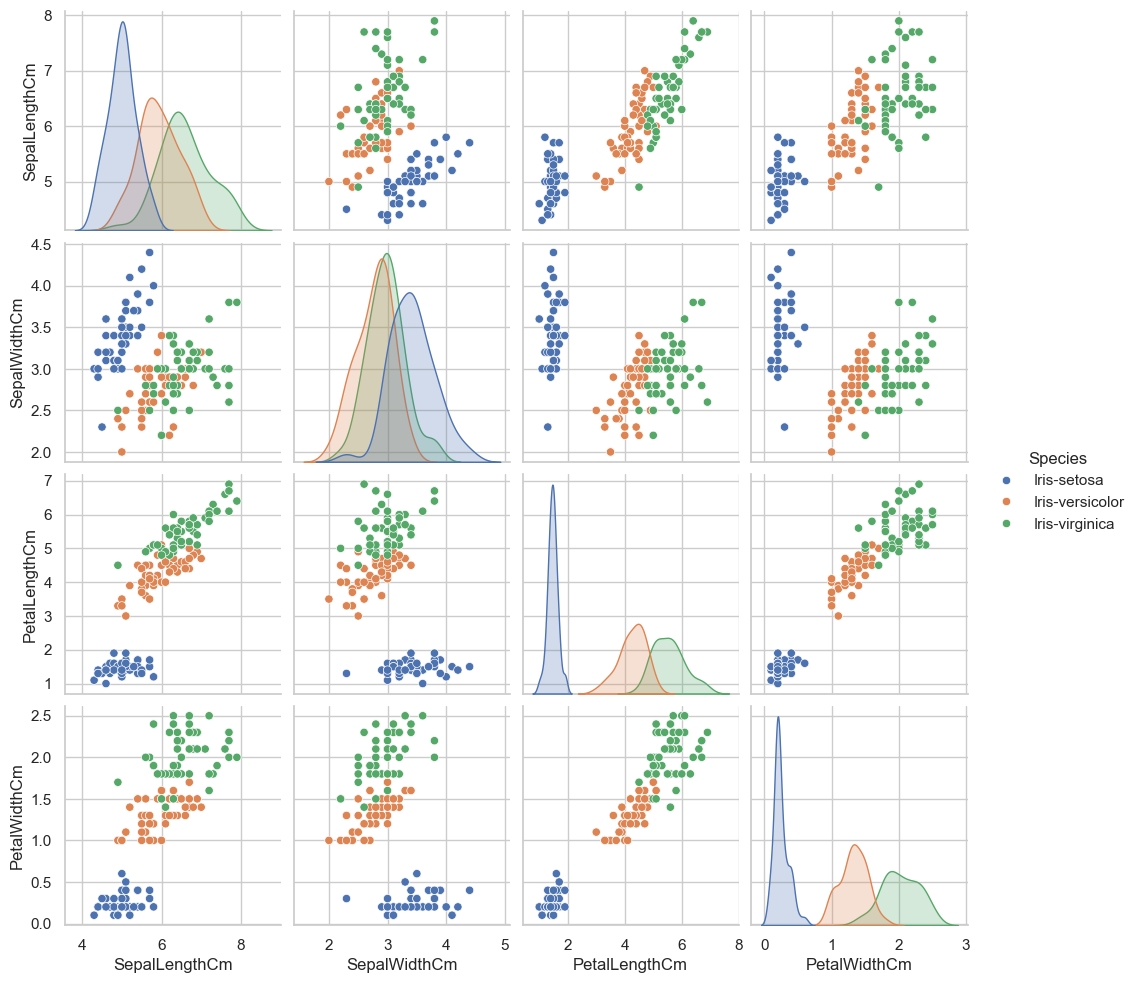

In [75]:
sns.pairplot(
    data=df,
    vars=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"],
    hue="Species"
)
plt.show()


### 2.6 Bar plot from grouped data


,Species,petal_area
0,Iris-setosa,0.3628
1,Iris-versicolor,5.7204
2,Iris-virginica,11.2962


<Figure size 700x500 with 0 Axes>

<Axes: xlabel='Species', ylabel='petal_area'>

Text(0.5, 1.0, 'Mean petal area by species')

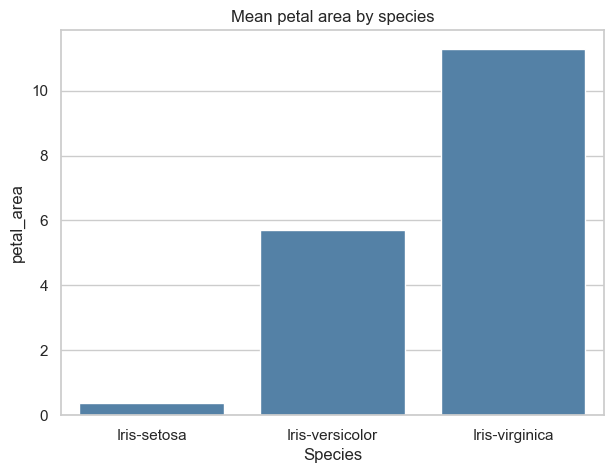

In [76]:
grouped = df.groupby("Species", as_index=False)["petal_area"].mean()
grouped

plt.figure(figsize=(7, 5))
sns.barplot(data=grouped, x="Species", y="petal_area", color="steelblue")
plt.title("Mean petal area by species")
plt.show()


### 2.7 Correlation heatmap


<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation matrix')

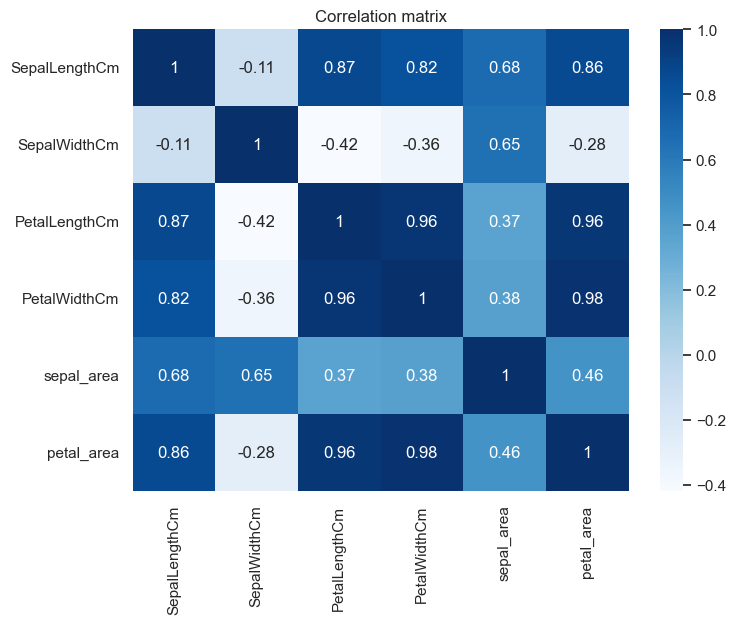

In [77]:
numeric_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "sepal_area", "petal_area"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation matrix")
plt.show()


## 3. Small pandas exercise with a second dataset


We now use the file `data/s1.csv`.

It contains two columns:
- `prenom`
- `nombre`

This dataset is useful for simple manipulations such as sorting, filtering, and visualization.


In [78]:
names = pd.read_csv("data/s1.csv")
names.head()
names.shape


,prenom,nombre
0,LUCAS,117001
1,EMMA,105209
2,ENZO,97980
3,LÉA,96491
4,HUGO,91960


(1000, 2)

In [79]:
names.sort_values(by="nombre", ascending=False).head(10)
names[names["nombre"] > 50000]


,prenom,nombre
0,LUCAS,117001
1,EMMA,105209
2,ENZO,97980
3,LÉA,96491
4,HUGO,91960
5,NATHAN,89252
6,MANON,88824
7,CAMILLE,87871
8,LOUIS,83448
9,CHLOÉ,82092


,prenom,nombre
0,LUCAS,117001
1,EMMA,105209
2,ENZO,97980
3,LÉA,96491
4,HUGO,91960
5,NATHAN,89252
6,MANON,88824
7,CAMILLE,87871
8,LOUIS,83448
9,CHLOÉ,82092


<Figure size 800x600 with 0 Axes>

<Axes: xlabel='nombre', ylabel='prenom'>

Text(0.5, 1.0, 'Top 10 most frequent names')

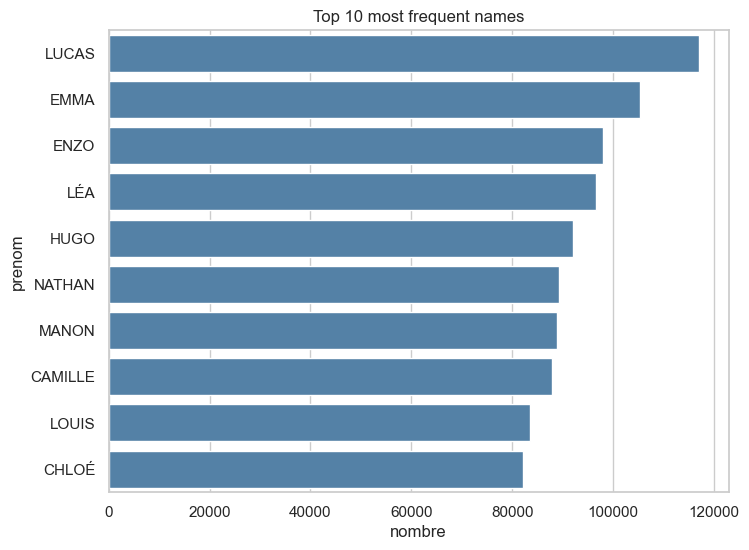

In [80]:
top10 = names.sort_values(by="nombre", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top10, x="nombre", y="prenom", color="steelblue")
plt.title("Top 10 most frequent names")
plt.show()


## 4. NumPy


This second part is more complete.

The goal is to practice:
- creating arrays,
- indexing and slicing,
- reshaping arrays,
- aggregation,
- matrix operations,
- broadcasting,
- and vectorization.


### 4.1 One-dimensional arrays: basic creation


In [81]:
a = np.array([1, 2, 3])
a

b = np.array(range(7))
b

t1 = 10 ** np.arange(11)
t1

t2 = np.arange(0, 101, 2)
t2

t3 = np.arange(0, -11, -1)
t3


array([1, 2, 3])

array([0, 1, 2, 3, 4, 5, 6])

array([         1,         10,        100,       1000,      10000,
           100000,    1000000,   10000000,  100000000, 1000000000,
       1410065408], dtype=int32)

array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
        26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
        52,  54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,
        78,  80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100])

array([  0,  -1,  -2,  -3,  -4,  -5,  -6,  -7,  -8,  -9, -10])

### 4.2 One-dimensional arrays: arange, linspace, and like-functions


In [82]:
c = np.arange(0, 10, 2)
c

d = np.linspace(0, 1, 6)
d

zeros = np.zeros((2, 3))
zeros

ones = np.ones((3, 2))
ones

same_zeros = np.zeros_like(a)
same_zeros

same_ones = np.ones_like(a)
same_ones

np.full((2, 3), 7)
np.full_like(a, 100)


array([0, 2, 4, 6, 8])

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

array([[0., 0., 0.],
       [0., 0., 0.]])

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

array([0, 0, 0])

array([1, 1, 1])

array([[7, 7, 7],
       [7, 7, 7]])

array([100, 100, 100])

### 4.3 One-dimensional indexing and slicing


In [83]:
a = np.arange(2, 12)
a

a[-2]
a[1:-2:3]
a[::2]
a[1::2]
a[::-1]


array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

10

array([3, 6, 9])

array([ 2,  4,  6,  8, 10])

array([ 3,  5,  7,  9, 11])

array([11, 10,  9,  8,  7,  6,  5,  4,  3,  2])

### 4.4 One-dimensional elementary operations


In [84]:
a + 10
a - 3
2 * a
a / 2
a ** 2
a % 2
np.sqrt(a)


array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21])

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8])

array([ 4,  6,  8, 10, 12, 14, 16, 18, 20, 22])

array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5])

array([  4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1], dtype=int32)

array([1.41421356, 1.73205081, 2.        , 2.23606798, 2.44948974,
       2.64575131, 2.82842712, 3.        , 3.16227766, 3.31662479])

### 4.5 One-dimensional aggregation


In [85]:
a.sum()
a.mean()
a.std()
a.var()
a.min()
a.max()
a.cumsum()
a.cumprod()


65

6.5

2.8722813232690143

8.25

2

11

array([ 2,  5,  9, 14, 20, 27, 35, 44, 54, 65])

array([       2,        6,       24,      120,      720,     5040,
          40320,   362880,  3628800, 39916800])

### 4.6 Manual formulas for the mean and the standard deviation


In [86]:
a.sum() / len(a)
np.sqrt(((a - a.mean()) ** 2).sum() / len(a))


6.5

2.8722813232690143

### 4.7 Multidimensional arrays: creation


In [87]:
A = np.array([[4, 5, 6], [7, 8, 9]])
B = np.zeros((2, 3, 4))
C = np.ones((3, 4))
D = np.full((2, 3), 3)
E = np.zeros_like(D)
F = np.ones_like(D)
G = np.full_like(D, 100)

A.shape, B.shape, C.shape, D.shape, E.shape, F.shape, G.shape


((2, 3), (2, 3, 4), (3, 4), (2, 3), (2, 3), (2, 3), (2, 3))

### 4.8 Matrix-specific constructors


In [88]:
np.diag([1, 0, 1])
np.eye(3)

A1 = np.array([[1], [-1], [0]])
A1

A2 = np.array([-3, -2, 1])
A2

A3 = np.full((3, 3), -2) + 2 * np.eye(3)
A3


array([[1, 0, 0],
       [0, 0, 0],
       [0, 0, 1]])

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

array([[ 1],
       [-1],
       [ 0]])

array([-3, -2,  1])

array([[ 0., -2., -2.],
       [-2.,  0., -2.],
       [-2., -2.,  0.]])

### 4.9 Reshape


In [89]:
a = np.arange(4, 10)
a

a.reshape((3, 2))
a.reshape((6, 1))


array([4, 5, 6, 7, 8, 9])

array([[4, 5],
       [6, 7],
       [8, 9]])

array([[4],
       [5],
       [6],
       [7],
       [8],
       [9]])

### 4.10 Reshape exercises with order


In [90]:
M1 = np.arange(1, 9).reshape((2, 4))
M1

M2 = np.arange(1, 9).reshape((2, 4), order="F")
M2


array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

array([[1, 3, 5, 7],
       [2, 4, 6, 8]])

### 4.11 Two-dimensional indexing


In [91]:
A = np.arange(12).reshape(3, 4)
A

A[0, 1]
A[0]
A[:, -1]
A[0:2, 1:3]
A[[0, 2], :]
A[:, [1, 3]]
A[A % 2 == 0]


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

1

array([0, 1, 2, 3])

array([ 3,  7, 11])

array([[1, 2],
       [5, 6]])

array([[ 0,  1,  2,  3],
       [ 8,  9, 10, 11]])

array([[ 1,  3],
       [ 5,  7],
       [ 9, 11]])

array([ 0,  2,  4,  6,  8, 10])

### 4.12 Interior of a matrix


In [92]:
A = np.arange(24).reshape(4, 6) + 1
A

A[1:-1, 1:-1]


array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24]])

array([[ 8,  9, 10, 11],
       [14, 15, 16, 17]])

### 4.13 Adding and removing dimensions


In [93]:
a = np.array([1, 2, 3])
(a.ndim, a.shape)

b = a[np.newaxis, :]
(b.ndim, b.shape)
b

c = a[:, np.newaxis]
(c.ndim, c.shape)
c

b.squeeze()
c.squeeze()


(1, (3,))

(2, (1, 3))

array([[1, 2, 3]])

(2, (3, 1))

array([[1],
       [2],
       [3]])

array([1, 2, 3])

array([1, 2, 3])

### 4.14 Function exercise: turn a column vector into a row vector


In [94]:
def transpose_vector(v):
    return v.squeeze()[np.newaxis, :]

v = np.array([[1], [2], [3]])
v
transpose_vector(v)


array([[1],
       [2],
       [3]])

array([[1, 2, 3]])

### 4.15 Concatenation


In [95]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
np.concatenate((a, b))

A = np.array([[1, 2, 3], [4, 5, 6]])
B = np.array([[7, 8, 9], [10, 11, 12]])

np.concatenate((A, B), axis=0)
np.vstack((A, B))

np.concatenate((A, B), axis=1)
np.hstack((A, B))


array([1, 2, 3, 4, 5, 6])

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

array([[ 1,  2,  3,  7,  8,  9],
       [ 4,  5,  6, 10, 11, 12]])

array([[ 1,  2,  3,  7,  8,  9],
       [ 4,  5,  6, 10, 11, 12]])

### 4.16 Function exercise: block matrix


In [96]:
def block_matrix(A1, A2):
    top = np.concatenate((A1, -A2), axis=1)
    bottom = np.concatenate((A2, A1), axis=1)
    return np.concatenate((top, bottom), axis=0)

block_matrix(np.diag([1, 2]), np.diag([3, 4]))


array([[ 1,  0, -3,  0],
       [ 0,  2,  0, -4],
       [ 3,  0,  1,  0],
       [ 0,  4,  0,  2]])

### 4.17 Stacking


In [97]:
a = np.array([1, 2])
b = np.array([3, 4])
c = np.stack((a, b))
c
(c.ndim, c.shape)

A = np.diag([1, 2, 3])
B = np.diag([4, 5, 6])

np.stack((A, B), axis=0).shape
np.stack((A, B), axis=1).shape
np.stack((A, B), axis=-1).shape


array([[1, 2],
       [3, 4]])

(2, (2, 2))

(2, 3, 3)

(3, 2, 3)

(3, 3, 2)

### 4.18 Two-dimensional elementary operations


In [98]:
A = np.array([[1, 4], [3, 2]])
B = np.array([[5, 6], [7, 8]])

A + 10
A - 10
3 * A
A / 10

A + B
A - B
A * B
A / B

A ** 2
A % 2

np.sqrt(A)
np.sin(A)
np.exp(A)


array([[11, 14],
       [13, 12]])

array([[-9, -6],
       [-7, -8]])

array([[ 3, 12],
       [ 9,  6]])

array([[0.1, 0.4],
       [0.3, 0.2]])

array([[ 6, 10],
       [10, 10]])

...

array([[ 1, 16],
       [ 9,  4]])

array([[1, 0],
       [1, 0]], dtype=int32)

array([[1.        , 2.        ],
       [1.73205081, 1.41421356]])

array([[ 0.84147098, -0.7568025 ],
       [ 0.14112001,  0.90929743]])

array([[ 2.71828183, 54.59815003],
       [20.08553692,  7.3890561 ]])

### 4.19 Two-dimensional aggregation


In [99]:
A = np.arange(1, 10).reshape((3, 3))
A

A.sum()
A.sum(axis=0)
A.sum(axis=1)

A.mean()
A.mean(axis=0)
A.mean(axis=1)

A.min()
A.min(axis=0)
A.min(axis=1)

A.max()
A.max(axis=0)
A.max(axis=1)

A.cumsum(axis=0)
A.cumsum(axis=1)


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

45

array([12, 15, 18])

array([ 6, 15, 24])

5.0

...

9

array([7, 8, 9])

array([3, 6, 9])

array([[ 1,  2,  3],
       [ 5,  7,  9],
       [12, 15, 18]])

array([[ 1,  3,  6],
       [ 4,  9, 15],
       [ 7, 15, 24]])

### 4.20 Matrix operations


In [100]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

np.dot(a, b)
a @ b

C = np.array([[1, 2], [3, 4]])
D = np.array([[0, 1], [1, 0]])

C @ D
C.T
np.trace(C)

C_inv = np.linalg.inv(C)
C_inv
C_inv @ C


32

32

array([[2, 1],
       [4, 3]])

array([[1, 3],
       [2, 4]])

5

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

array([[1.0000000e+00, 4.4408921e-16],
       [0.0000000e+00, 1.0000000e+00]])

### 4.21 Function exercise: harmonic matrix with broadcasting


In [101]:
def harmonic_matrix(n, p):
    u = np.arange(1, n + 1)[:, np.newaxis]
    v = np.arange(1, p + 1)[np.newaxis, :]
    return 1 / (u @ v)

harmonic_matrix(2, 3)


array([[1.        , 0.5       , 0.33333333],
       [0.5       , 0.25      , 0.16666667]])

### 4.22 Broadcasting: compatible and incompatible shapes


In [102]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

B = np.array([10, 20, 30])
A + B

C = np.array([[10], [20]])
A + C


array([[11, 22, 33],
       [14, 25, 36]])

array([[11, 12, 13],
       [24, 25, 26]])

In [103]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])
D = np.array([10, 20])

try:
    A + D
except ValueError as e:
    print("Broadcasting error:", e)


Broadcasting error: operands could not be broadcast together with shapes (2,3) (2,) 


### 4.23 Vectorization: pairwise Euclidean distances


We consider a dataset `X` with `N` samples and `D` features.

The goal is to compute the Euclidean distance between every pair of samples:
$$
d(x_i, x_j) = \sqrt{\sum_{k=1}^{D}(x_{ik} - x_{jk})^2}.
$$

First, we prepare the data.


In [104]:
import time

np.random.seed(0)
N = 4000
D = 10

X = np.random.randint(0, 101, size=(N, D))
X.shape


(4000, 10)

In [105]:
D_loop = np.zeros((N, N))

start = time.time()
for i in range(N):
    for j in range(N):
        D_loop[i, j] = np.sqrt(np.sum((X[i] - X[j]) ** 2))
end = time.time()

print("Loop time:", end - start)
D_loop[:3, :3]


Loop time: 56.60295748710632


array([[  0.        , 124.77179168, 108.24971132],
       [124.77179168,   0.        , 123.56374873],
       [108.24971132, 123.56374873,   0.        ]])

Now compute the same result in a **vectorized** way using the identity

$$
\|x_i - x_j\|^2 = \|x_i\|^2 + \|x_j\|^2 - 2 x_i^{\top} x_j.
$$


In [106]:
start = time.time()

sum_X = np.sum(X ** 2, axis=1)
D2 = sum_X[:, np.newaxis] + sum_X[np.newaxis, :] - 2 * (X @ X.T)
D2[D2 < 0] = 0
D_vec = np.sqrt(D2)

end = time.time()

print("Vectorized time:", end - start)
D_vec[:3, :3]
np.allclose(D_loop, D_vec)


Vectorized time: 0.2082991600036621


array([[  0.        , 124.77179168, 108.24971132],
       [124.77179168,   0.        , 123.56374873],
       [108.24971132, 123.56374873,   0.        ]])

True